# Module 1 — Language Detection

Classifies the language of a user message using TF-IDF and LinearSVC.

This notebook trains several model variants (`build_model_1` … `build_model_4`), compares them on train / validation / test splits, plots a learning curve with repeated test checks, then saves the best model to `models/language_detector.joblib`.

Import libraries

In [6]:
%matplotlib inline

from __future__ import annotations

from pathlib import Path
from typing import List, Sequence

import joblib
import pandas as pd
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import LinearSVC


Global paths

In [7]:
from pathlib import Path

# Repo root when cwd is repo root or notebooks/
_cwd = Path.cwd().resolve()
PROJECT_ROOT = _cwd if (_cwd / "models").is_dir() else _cwd.parent

MODEL_PATH = PROJECT_ROOT / "models" / "language_detector.joblib"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "module1"
METRICS_DIR = OUTPUT_DIR / "metrics"

CM_CSV_PATH = METRICS_DIR / "language_detector.confusion_matrix.csv"
CM_PNG_PATH = METRICS_DIR / "language_detector.confusion_matrix.png"
COMPARISON_CSV_PATH = METRICS_DIR / "model_comparison.csv"
LEARNING_CURVE_CSV_PATH = METRICS_DIR / "learning_curve.csv"
LEARNING_CURVE_PNG_PATH = METRICS_DIR / "learning_curve.png"

for path in (OUTPUT_DIR, METRICS_DIR, MODEL_PATH.parent):
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Model will save to:", MODEL_PATH)
print("Outputs will save to:", OUTPUT_DIR)
print("Metrics will save to:", METRICS_DIR)

Project root: /home/magdy/magdy/NLP/Mental-Health-RAG-Chatbot
Model will save to: /home/magdy/magdy/NLP/Mental-Health-RAG-Chatbot/models/language_detector.joblib
Outputs will save to: /home/magdy/magdy/NLP/Mental-Health-RAG-Chatbot/outputs/module1
Metrics will save to: /home/magdy/magdy/NLP/Mental-Health-RAG-Chatbot/outputs/module1/metrics


In [8]:
def _make_pipeline(feature_blocks: list, C: float = 1.0) -> Pipeline:
    features = FeatureUnion(feature_blocks, n_jobs=1)
    return Pipeline([("features", features), ("clf", LinearSVC(C=C))])


def build_model_1() -> Pipeline:
    """Full model: char + char_wb + word n-grams (best accuracy, slower)."""
    return _make_pipeline(
        [
            (
                "char",
                TfidfVectorizer(
                    analyzer="char",
                    ngram_range=(2, 6),
                    sublinear_tf=True,
                    min_df=2,
                    lowercase=True,
                    max_features=300_000,
                ),
            ),
            (
                "char_wb",
                TfidfVectorizer(
                    analyzer="char_wb",
                    ngram_range=(3, 7),
                    sublinear_tf=True,
                    min_df=2,
                    lowercase=True,
                    max_features=200_000,
                ),
            ),
            (
                "word",
                TfidfVectorizer(
                    analyzer="word",
                    ngram_range=(1, 2),
                    sublinear_tf=True,
                    min_df=2,
                    lowercase=True,
                    max_features=200_000,
                ),
            ),
        ],
        C=3.0,
    )


def build_model_2() -> Pipeline:
    """Char-only model: faster training, good for scripts / quick experiments."""
    return _make_pipeline(
        [
            (
                "char",
                TfidfVectorizer(
                    analyzer="char",
                    ngram_range=(2, 5),
                    sublinear_tf=True,
                    min_df=2,
                    lowercase=True,
                    max_features=150_000,
                ),
            ),
        ],
        C=2.0,
    )


def build_model_3() -> Pipeline:
    """Word + char_wb: lighter than model_1, stronger on token boundaries."""
    return _make_pipeline(
        [
            (
                "char_wb",
                TfidfVectorizer(
                    analyzer="char_wb",
                    ngram_range=(3, 6),
                    sublinear_tf=True,
                    min_df=2,
                    lowercase=True,
                    max_features=200_000,
                ),
            ),
            (
                "word",
                TfidfVectorizer(
                    analyzer="word",
                    ngram_range=(1, 3),
                    sublinear_tf=True,
                    min_df=2,
                    lowercase=True,
                    max_features=150_000,
                ),
            ),
        ],
        C=1.5,
    )


def build_model_4() -> Pipeline:
    """Compact char model: smallest feature space, fastest fit."""
    return _make_pipeline(
        [
            (
                "char",
                TfidfVectorizer(
                    analyzer="char",
                    ngram_range=(3, 5),
                    sublinear_tf=True,
                    min_df=3,
                    lowercase=True,
                    max_features=80_000,
                ),
            ),
        ],
        C=1.0,
    )


MODEL_BUILDERS = {
    "model_1_full": build_model_1,
    "model_2_char_only": build_model_2,
    "model_3_word_charwb": build_model_3,
    "model_4_compact": build_model_4,
}


def evaluate_split(model: Pipeline, x: Sequence[str], y: Sequence[str], split_name: str) -> dict:
    preds = model.predict(x)
    return {
        "split": split_name,
        "n_samples": len(y),
        "accuracy": accuracy_score(y, preds),
    }


def fit_and_score(
    builder,
    name: str,
    x_train_fit: Sequence[str],
    y_train_fit: Sequence[str],
    eval_splits: dict[str, tuple[Sequence[str], Sequence[str]]],
) -> tuple[Pipeline, pd.DataFrame]:
    print(f"\n{'=' * 60}\nTraining: {name}\n{'=' * 60}")
    model = builder()
    model.fit(x_train_fit, y_train_fit)

    rows = [{"model": name, **evaluate_split(model, x, y, split)} for split, (x, y) in eval_splits.items()]
    scores = pd.DataFrame(rows)
    print(scores.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    return model, scores


def training_size_curve(
    builder,
    x_train_fit: Sequence[str],
    y_train_fit: Sequence[str],
    x_test_eval: Sequence[str],
    y_test_eval: Sequence[str],
    fractions: tuple[float, ...] = (0.1, 0.2, 0.4, 0.6, 0.8, 1.0),
    random_state: int = 42,
) -> pd.DataFrame:
    """Repeated test checks while increasing training data (simulates training progress)."""
    import numpy as np

    rng = np.random.default_rng(random_state)
    indices = rng.permutation(len(x_train_fit))
    rows = []

    for frac in fractions:
        n = max(100, int(len(x_train_fit) * frac))
        idx = indices[:n]
        x_sub = [x_train_fit[i] for i in idx]
        y_sub = [y_train_fit[i] for i in idx]

        model = builder()
        model.fit(x_sub, y_sub)
        train_acc = accuracy_score(y_sub, model.predict(x_sub))
        test_acc = accuracy_score(y_test_eval, model.predict(x_test_eval))
        rows.append(
            {
                "train_fraction": frac,
                "train_samples": n,
                "train_accuracy": train_acc,
                "test_accuracy": test_acc,
            }
        )
        print(
            f"  fraction={frac:4.0%} | train_n={n:6d} | "
            f"train_acc={train_acc:.4f} | test_acc={test_acc:.4f}"
        )

    return pd.DataFrame(rows)


def plot_learning_curve(df: pd.DataFrame, path: Path) -> None:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(df["train_samples"], df["train_accuracy"], marker="o", label="Train accuracy")
    ax.plot(df["train_samples"], df["test_accuracy"], marker="s", label="Test accuracy")
    ax.set_xlabel("Training samples used")
    ax.set_ylabel("Accuracy")
    ax.set_title("Language detection — accuracy vs training size")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def save_confusion_matrix_png(cm, labels: List[str], path: Path, title: str = "Language detection — confusion matrix (test)") -> None:
    import matplotlib.pyplot as plt

    n = len(labels)
    size = max(10.0, n * 0.35)
    fig, ax = plt.subplots(figsize=(size, size))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=90, ha="right", fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## Load dataset

In [9]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split

dataset = load_dataset("papluca/language-identification")

x_train_full = list(dataset["train"]["text"])
y_train_full = list(dataset["train"]["labels"])
x_test = list(dataset["test"]["text"])
y_test = list(dataset["test"]["labels"])

# Hold-out validation for many checks during training (stratified)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.1,
    random_state=42,
    stratify=y_train_full,
)

print("Train size (fit):", len(x_train))
print("Validation size:", len(x_val))
print("Test size:", len(x_test))
print("Languages:", sorted(set(y_train_full)))

pd.DataFrame({"text": x_train[:5], "label": y_train[:5]})

Train size (fit): 63000
Validation size: 7000
Test size: 10000
Languages: ['ar', 'bg', 'de', 'el', 'en', 'es', 'fr', 'hi', 'it', 'ja', 'nl', 'pl', 'pt', 'ru', 'sw', 'th', 'tr', 'ur', 'vi', 'zh']


,text,label
0,Ne guidi uno?,it
1,Een witte en bruine hond loopt over het gras.,nl
2,"Roman fretard , thay vì một danh sách các nhà ...",vi
3,Glas passt nicht 100%,de
4,Great cords I would like to see my cat chew th...,en


## Compare model variants (train / val / test)

In [10]:
EVAL_SPLITS = {
    "train": (x_train, y_train),
    "val": (x_val, y_val),
    "test": (x_test, y_test),
}

all_scores: list[pd.DataFrame] = []
trained_models: dict[str, Pipeline] = {}

for name, builder in MODEL_BUILDERS.items():
    model, scores = fit_and_score(builder, name, x_train, y_train, EVAL_SPLITS)
    trained_models[name] = model
    all_scores.append(scores)

comparison = pd.concat(all_scores, ignore_index=True)
comparison_pivot = comparison.pivot(index="model", columns="split", values="accuracy")
comparison_pivot = comparison_pivot[["train", "val", "test"]]

print("\n" + "=" * 60)
print("Model comparison (accuracy)")
print("=" * 60)
display(comparison_pivot.style.format("{:.4f}").highlight_max(axis=0, color="#c8e6c9"))

comparison.to_csv(COMPARISON_CSV_PATH, index=False)
print(f"\nSaved comparison -> {COMPARISON_CSV_PATH}")

best_row = comparison.loc[comparison["split"] == "val"].sort_values("accuracy", ascending=False).iloc[0]
BEST_MODEL_NAME = best_row["model"]
print(f"\nBest on validation: {BEST_MODEL_NAME} (val acc = {best_row['accuracy']:.4f})")


Training: model_1_full
       model split  n_samples  accuracy
model_1_full train      63000    0.9998
model_1_full   val       7000    0.9963
model_1_full  test      10000    0.9958

Training: model_2_char_only
            model split  n_samples  accuracy
model_2_char_only train      63000    0.9998
model_2_char_only   val       7000    0.9970
model_2_char_only  test      10000    0.9954

Training: model_3_word_charwb
              model split  n_samples  accuracy
model_3_word_charwb train      63000    0.9998
model_3_word_charwb   val       7000    0.9951
model_3_word_charwb  test      10000    0.9936

Training: model_4_compact
          model split  n_samples  accuracy
model_4_compact train      63000    0.9995
model_4_compact   val       7000    0.9953
model_4_compact  test      10000    0.9918

Model comparison (accuracy)


split,train,val,test
model,,,
model_1_full,0.9998,0.9963,0.9958
model_2_char_only,0.9998,0.9970,0.9954
model_3_word_charwb,0.9998,0.9951,0.9936
model_4_compact,0.9995,0.9953,0.9918



Saved comparison -> /home/magdy/magdy/NLP/Mental-Health-RAG-Chatbot/outputs/module1/metrics/model_comparison.csv

Best on validation: model_2_char_only (val acc = 0.9970)


## Training progress — repeated test checks (best model)

Fit the validation winner on increasing fractions of the training set and score on the held-out test set after each step.

Learning curve for: model_2_char_only

  fraction= 10% | train_n=  6300 | train_acc=1.0000 | test_acc=0.9934
  fraction= 20% | train_n= 12600 | train_acc=1.0000 | test_acc=0.9939
  fraction= 40% | train_n= 25200 | train_acc=1.0000 | test_acc=0.9944
  fraction= 60% | train_n= 37800 | train_acc=0.9999 | test_acc=0.9955
  fraction= 80% | train_n= 50400 | train_acc=0.9999 | test_acc=0.9954
  fraction=100% | train_n= 63000 | train_acc=0.9998 | test_acc=0.9954


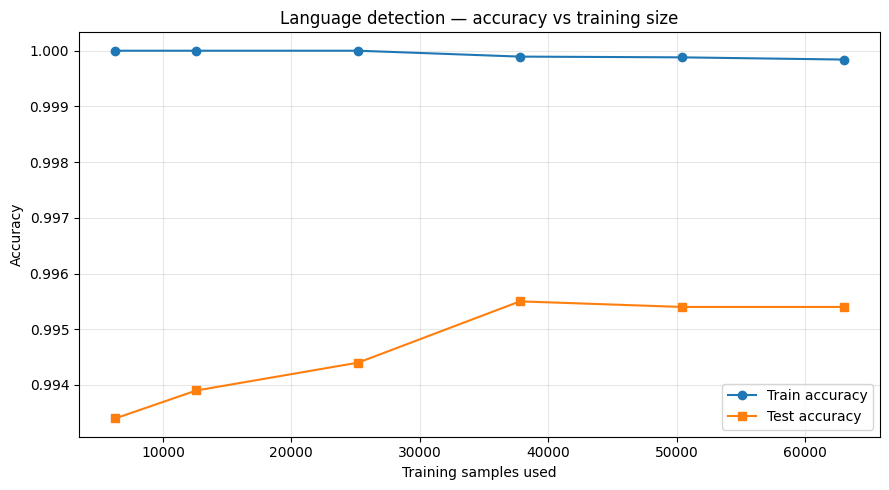


Saved learning curve -> /home/magdy/magdy/NLP/Mental-Health-RAG-Chatbot/outputs/module1/metrics/learning_curve.csv
Saved plot -> /home/magdy/magdy/NLP/Mental-Health-RAG-Chatbot/outputs/module1/metrics/learning_curve.png


,train_fraction,train_samples,train_accuracy,test_accuracy
0,10%,6300,1.0000,0.9934
1,20%,12600,1.0000,0.9939
2,40%,25200,1.0000,0.9944
3,60%,37800,0.9999,0.9955
4,80%,50400,0.9999,0.9954
5,100%,63000,0.9998,0.9954


In [11]:
print(f"Learning curve for: {BEST_MODEL_NAME}\n")
learning_df = training_size_curve(
    MODEL_BUILDERS[BEST_MODEL_NAME],
    x_train,
    y_train,
    x_test,
    y_test,
)

learning_df.to_csv(LEARNING_CURVE_CSV_PATH, index=False)
plot_learning_curve(learning_df, LEARNING_CURVE_PNG_PATH)
print(f"\nSaved learning curve -> {LEARNING_CURVE_CSV_PATH}")
print(f"Saved plot -> {LEARNING_CURVE_PNG_PATH}")
display(learning_df.style.format({"train_fraction": "{:.0%}", "train_accuracy": "{:.4f}", "test_accuracy": "{:.4f}"}))

## Final model — retrain on full train split and evaluate on test

Fitting final model (model_2_char_only) on 70,000 samples...


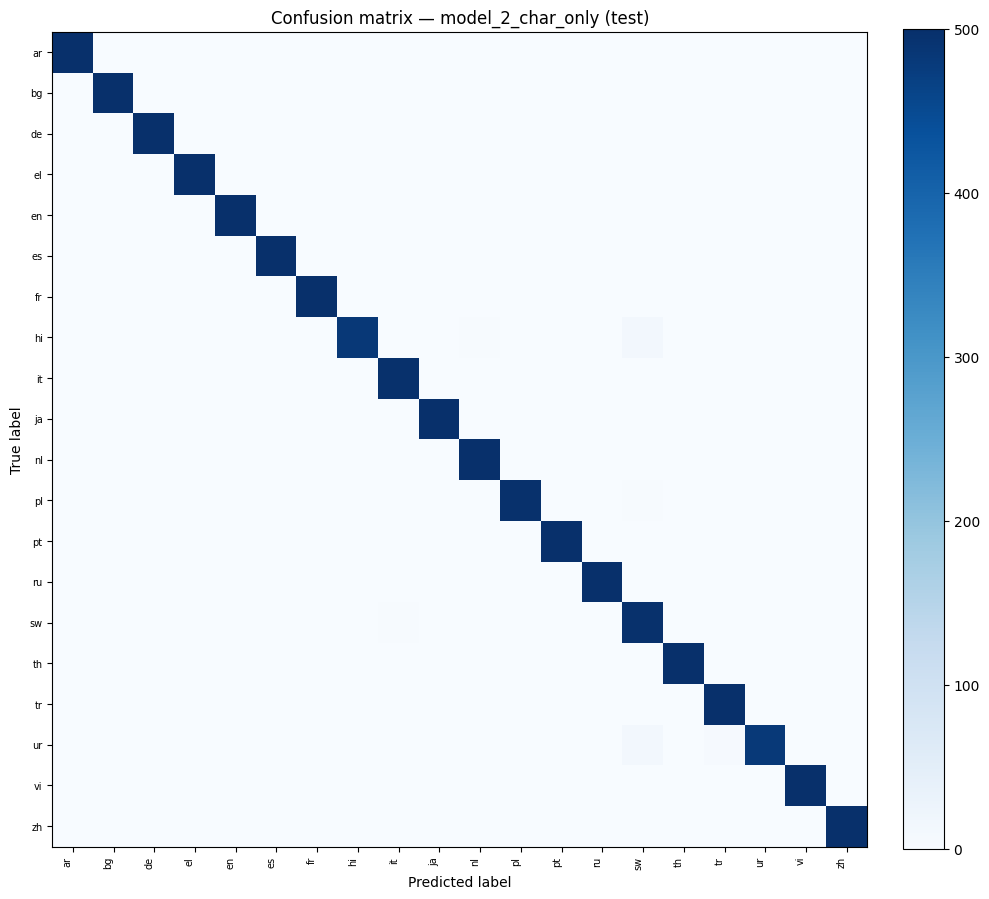


Test accuracy: 0.9953
Saved model -> /home/magdy/magdy/NLP/Mental-Health-RAG-Chatbot/models/language_detector.joblib
Saved confusion matrix -> /home/magdy/magdy/NLP/Mental-Health-RAG-Chatbot/outputs/module1/metrics/language_detector.confusion_matrix.csv
Saved confusion matrix plot -> /home/magdy/magdy/NLP/Mental-Health-RAG-Chatbot/outputs/module1/metrics/language_detector.confusion_matrix.png

              precision    recall  f1-score   support

          ar     1.0000    0.9980    0.9990       500
          bg     0.9980    1.0000    0.9990       500
          de     1.0000    1.0000    1.0000       500
          el     1.0000    1.0000    1.0000       500
          en     0.9960    1.0000    0.9980       500
          es     0.9980    0.9980    0.9980       500
          fr     0.9980    1.0000    0.9990       500
          hi     1.0000    0.9680    0.9837       500
          it     0.9940    0.9960    0.9950       500
          ja     1.0000    1.0000    1.0000       500
       

In [12]:
# Retrain best architecture on train + validation before deployment
x_train_all = x_train + x_val
y_train_all = y_train + y_val

model = MODEL_BUILDERS[BEST_MODEL_NAME]()
print(f"Fitting final model ({BEST_MODEL_NAME}) on {len(x_train_all):,} samples...")
model.fit(x_train_all, y_train_all)

preds = model.predict(x_test)
test_accuracy = accuracy_score(y_test, preds)
report = classification_report(y_test, preds, digits=4)

labels = sorted(set(y_test) | set(preds))
cm = confusion_matrix(y_test, preds, labels=labels)

pd.DataFrame(cm, index=labels, columns=labels).to_csv(CM_CSV_PATH)
save_confusion_matrix_png(cm, labels, CM_PNG_PATH, title=f"Confusion matrix — {BEST_MODEL_NAME} (test)")
joblib.dump(model, MODEL_PATH)

print(f"\nTest accuracy: {test_accuracy:.4f}")
print(f"Saved model -> {MODEL_PATH}")
print(f"Saved confusion matrix -> {CM_CSV_PATH}")
print(f"Saved confusion matrix plot -> {CM_PNG_PATH}")
print()
print(report)

In [13]:
# Quick demo — final model in action
demo_texts = [
    ("en", "I have been feeling anxious and overwhelmed for the past few weeks."),
    ("ar", "كيف حالك اليوم؟ أشعر بالقلق منذ عدة أيام."),
    ("fr", "Bonjour, comment allez-vous aujourd'hui ?"),
    ("de", "Wie geht es Ihnen heute? Ich schlafe schlecht."),
    ("ja", "こんにちは、お元気ですか？最近よく眠れません。"),
]

print(f"=== DEMO ({BEST_MODEL_NAME}) ===\n")
for expected, text in demo_texts:
    pred = model.predict([text])[0]
    ok = "OK" if pred == expected else "??"
    snippet = text if len(text) <= 48 else text[:45] + "..."
    print(f"  [{ok}] expected={expected} predicted={pred} | {snippet}")

=== DEMO (model_2_char_only) ===

  [OK] expected=en predicted=en | I have been feeling anxious and overwhelmed f...
  [OK] expected=ar predicted=ar | كيف حالك اليوم؟ أشعر بالقلق منذ عدة أيام.
  [OK] expected=fr predicted=fr | Bonjour, comment allez-vous aujourd'hui ?
  [OK] expected=de predicted=de | Wie geht es Ihnen heute? Ich schlafe schlecht.
  [OK] expected=ja predicted=ja | こんにちは、お元気ですか？最近よく眠れません。
